# Cheap Talk Signaling Game — Analysis Pipeline
**ESADE MIBA 2026 · Capstone P264**

This notebook loads raw experiment output CSVs, computes all metrics from scratch, and reproduces the visualisations shown in the HTML summary report.  
Every number in the report traces back to a computed variable in this file — no hardcoded constants.

---
### Experimental Design Notes
- **`undisclosed` condition** uses **10 rounds/game** — this is the finalised best-practice protocol.
- **All other conditions** use **15 rounds/game** — these were preliminary data-collection runs before the protocol was locked.
- Temperatures swept: **0.2, 0.6, 0.8**. The `undisclosed` condition has two replications at T=0.6 (kept for additional statistical power); all other conditions have one file per temperature.
- `run_id` resets to 1 within each CSV file. A global `global_run_id` is assigned on load to uniquely identify every run across the full dataset.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings, pathlib, json
warnings.filterwarnings('ignore')

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 120,
})

BLUE   = '#2563EB'
TEAL   = '#0D9488'
AMBER  = '#D97706'
RED    = '#DC2626'
PURPLE = '#7C3AED'
GRAY   = '#6B7280'

MODEL_COLORS = {
    'Claude Opus':              BLUE,
    'Claude Sonnet':            '#60A5FA',
    'GPT-4o':                   TEAL,
    'GPT-4o-mini':              '#34D399',
    'Gemini 2.5 Flash':         AMBER,
    'Gemini 2.5 Flash Lite':    '#FCD34D',
    'Human Prior (Gneezy 2005)':RED,
}

print('Libraries loaded.')

Libraries loaded.


## 1. Load & Merge Data

In [2]:
# ── File manifest ─────────────────────────────────────────────────────────────
# Each entry: (filepath, label used in global_run_id)
# undisclosed: 4 files (2 × T=0.6 kept for statistical power, 1 × T=0.2, 1 × T=0.8)
# all other conditions: 3 files (one per temperature)

DATA_DIR = pathlib.Path('.')   # ← change this to the folder containing your CSVs

FILE_MANIFEST = [
    # undisclosed (10 rounds — final protocol)
    ('cheap_talk_results_undisclosed_20260519_072229.csv', 'undisclosed_T06_run1'),
    ('cheap_talk_results_undisclosed_20260519_073739.csv', 'undisclosed_T06_run2'),
    ('cheap_talk_results_undisclosed_20260519_141812.csv', 'undisclosed_T02'),
    ('cheap_talk_results_undisclosed_20260519_172858.csv', 'undisclosed_T08'),
    # ai_vs_ai (15 rounds — preliminary)
    ('cheap_talk_results_ai_vs_ai_20260520_063313.csv',    'ai_vs_ai_T02'),
    ('cheap_talk_results_ai_vs_ai_20260520_055922.csv',    'ai_vs_ai_T06'),
    ('cheap_talk_results_ai_vs_ai_20260520_070206.csv',    'ai_vs_ai_T08'),
    # ai_vs_human_blind (15 rounds — preliminary)
    ('cheap_talk_results_ai_vs_human_blind_20260520_144449.csv', 'blind_T02'),
    ('cheap_talk_results_ai_vs_human_blind_20260520_113515.csv', 'blind_T06'),
    ('cheap_talk_results_ai_vs_human_blind_20260520_152832.csv', 'blind_T08'),
    # ai_vs_human_informed (15 rounds — preliminary)
    ('cheap_talk_results_ai_vs_human_informed_20260520_095422.csv', 'informed_T02'),
    ('cheap_talk_results_ai_vs_human_informed_20260520_074807.csv', 'informed_T06'),
    ('cheap_talk_results_ai_vs_human_informed_20260520_103925.csv', 'informed_T08'),
    # human_prior (15 rounds — preliminary)
    ('cheap_talk_results_human_prior_20260520_191013.csv', 'human_prior_T02'),
    ('cheap_talk_results_human_prior_20260520_185511.csv', 'human_prior_T06'),
    ('cheap_talk_results_human_prior_20260520_193215.csv', 'human_prior_T08'),
]

frames = []
global_run_counter = 0

for filename, file_label in FILE_MANIFEST:
    path = DATA_DIR / filename
    df = pd.read_csv(path)
    # Assign globally unique run IDs: "<file_label>_r<N>"
    run_map = {local_id: f"{file_label}_r{i+1}"
               for i, local_id in enumerate(sorted(df['run_id'].unique()))}
    df['global_run_id'] = df['run_id'].map(run_map)
    df['file_label'] = file_label
    frames.append(df)

raw = pd.concat(frames, ignore_index=True)

# ── Derived columns ───────────────────────────────────────────────────────────
def model_family(name):
    if pd.isna(name): return 'Unknown'
    if 'Claude' in name:  return 'Anthropic'
    if 'GPT'   in name:   return 'OpenAI'
    if 'Gemini' in name:  return 'Google'
    if 'Human' in name:   return 'Human'
    return 'Unknown'

raw['sender_family']   = raw['model_sender'].apply(model_family)
raw['receiver_family'] = raw['model_receiver'].apply(model_family)
raw['same_family']     = raw['sender_family'] == raw['receiver_family']
raw['deception_rate']  = 1 - raw['message_truthful']   # alias for readability

print(f'Total rows loaded : {len(raw):,}')
print(f'Files loaded      : {len(FILE_MANIFEST)}')
print(f'Conditions        : {sorted(raw["identity_condition"].unique())}')

Total rows loaded : 7,380
Files loaded      : 16
Conditions        : ['ai_vs_ai', 'ai_vs_human_blind', 'ai_vs_human_informed', 'human_prior', 'undisclosed']


## 2. Data Audit — Runs, Rounds & Completeness

In [3]:
print('=' * 72)
print('EXPERIMENT INVENTORY')
print('=' * 72)

summary_rows = []

for cond in sorted(raw['identity_condition'].unique()):
    sub = raw[raw['identity_condition'] == cond]
    n_files       = sub['file_label'].nunique()
    temps         = sorted(sub['temperature_sender'].unique())
    n_matchups    = sub['matchup'].nunique()
    n_game_cond   = sub['game_condition'].nunique()
    rounds_per_game = sub['round'].max()
    n_global_runs = sub['global_run_id'].nunique()
    n_rounds_total = len(sub)

    # Runs per matchup × game_condition
    runs_breakdown = (
        sub.groupby(['matchup', 'game_condition'])['global_run_id']
        .nunique()
        .reset_index()
        .rename(columns={'global_run_id': 'n_runs'})
    )
    runs_per_cell = runs_breakdown['n_runs'].mean()

    protocol = '10 rounds (final)' if rounds_per_game == 10 else '15 rounds (preliminary)'

    print(f"\nCondition : {cond}")
    print(f"  Protocol        : {protocol}")
    print(f"  Files           : {n_files}")
    print(f"  Temperatures    : {temps}")
    print(f"  Matchups        : {n_matchups}")
    print(f"  Game conditions : {sorted(sub['game_condition'].unique())}")
    print(f"  Runs per cell   : {runs_per_cell:.1f} (matchup × game_condition)")
    print(f"  Total runs      : {n_global_runs}")
    print(f"  Total rounds    : {n_rounds_total:,}")

    summary_rows.append({
        'Condition':       cond,
        'Protocol':        protocol,
        'Files':           n_files,
        'Temperatures':    str(temps),
        'Matchups':        n_matchups,
        'Total runs':      n_global_runs,
        'Total rounds':    n_rounds_total,
    })

print()
print('=' * 72)
print('GRAND TOTALS')
print(f"  Total files   : {len(FILE_MANIFEST)}")
print(f"  Total runs    : {raw['global_run_id'].nunique():,}")
print(f"  Total rounds  : {len(raw):,}")
print('=' * 72)

inventory_df = pd.DataFrame(summary_rows)
display(inventory_df)

EXPERIMENT INVENTORY

Condition : ai_vs_ai
  Protocol        : 15 rounds (preliminary)
  Files           : 3
  Temperatures    : [np.float64(0.2), np.float64(0.6), np.float64(0.8)]
  Matchups        : 12
  Game conditions : ['aligned', 'misaligned']
  Runs per cell   : 4.5 (matchup × game_condition)
  Total runs      : 108
  Total rounds    : 1,620

Condition : ai_vs_human_blind
  Protocol        : 15 rounds (preliminary)
  Files           : 3
  Temperatures    : [np.float64(0.2), np.float64(0.6), np.float64(0.8)]
  Matchups        : 12
  Game conditions : ['aligned', 'misaligned']
  Runs per cell   : 4.5 (matchup × game_condition)
  Total runs      : 108
  Total rounds    : 1,620

Condition : ai_vs_human_informed
  Protocol        : 15 rounds (preliminary)
  Files           : 3
  Temperatures    : [np.float64(0.2), np.float64(0.6), np.float64(0.8)]
  Matchups        : 12
  Game conditions : ['aligned', 'misaligned']
  Runs per cell   : 4.5 (matchup × game_condition)
  Total runs      

,Condition,Protocol,Files,Temperatures,Matchups,Total runs,Total rounds
0,ai_vs_ai,15 rounds (preliminary),3,"[np.float64(0.2), np.float64(0.6), np.float64(...",12,108,1620
1,ai_vs_human_blind,15 rounds (preliminary),3,"[np.float64(0.2), np.float64(0.6), np.float64(...",12,108,1620
2,ai_vs_human_informed,15 rounds (preliminary),3,"[np.float64(0.2), np.float64(0.6), np.float64(...",12,108,1620
3,human_prior,15 rounds (preliminary),3,"[np.float64(0.2), np.float64(0.6), np.float64(...",8,48,720
4,undisclosed,15 rounds (preliminary),4,"[np.float64(0.2), np.float64(0.6), np.float64(...",12,144,1800


## 3. Core Metric Computation

In [4]:
def mean_ci(series, confidence=0.95):
    """Return (mean, lower_ci, upper_ci) for a boolean/numeric series."""
    n    = len(series)
    mean = series.mean()
    se   = series.std() / np.sqrt(n) if n > 1 else 0
    t    = stats.t.ppf((1 + confidence) / 2, df=max(n - 1, 1))
    return mean, mean - t * se, mean + t * se

# ── 3a. Overall metrics by condition × game_condition ─────────────────────────
records = []
for (id_cond, game_cond), g in raw.groupby(['identity_condition', 'game_condition']):
    truth_m,  truth_lo,  truth_hi  = mean_ci(g['message_truthful'])
    acc_m,    acc_lo,    acc_hi    = mean_ci(g['action_correct'])
    decep_m,  decep_lo,  decep_hi  = mean_ci(g['deception_success'])
    records.append({
        'identity_condition': id_cond,
        'game_condition':     game_cond,
        'truthfulness':       truth_m,
        'truthfulness_lo':    truth_lo,
        'truthfulness_hi':    truth_hi,
        'action_accuracy':    acc_m,
        'action_acc_lo':      acc_lo,
        'action_acc_hi':      acc_hi,
        'deception_success':  decep_m,
        'deception_succ_lo':  decep_lo,
        'deception_succ_hi':  decep_hi,
        'n_rounds':           len(g),
    })

metrics_df = pd.DataFrame(records)

# ── 3b. Deception rate by sender model × game_condition ───────────────────────
sender_records = []
for (model, game_cond), g in raw.groupby(['model_sender', 'game_condition']):
    dr_m, dr_lo, dr_hi = mean_ci(1 - g['message_truthful'])
    sender_records.append({
        'model_sender':      model,
        'game_condition':    game_cond,
        'deception_rate':    dr_m,
        'deception_rate_lo': dr_lo,
        'deception_rate_hi': dr_hi,
        'n_rounds':          len(g),
    })
sender_df = pd.DataFrame(sender_records)

# ── 3c. Receiver susceptibility (misaligned only) ─────────────────────────────
mis = raw[raw['game_condition'] == 'misaligned']
receiver_records = []
for model, g in mis.groupby('model_receiver'):
    acc_m, acc_lo, acc_hi = mean_ci(g['action_correct'])
    receiver_records.append({
        'model_receiver':   model,
        'action_accuracy':  acc_m,
        'acc_lo':           acc_lo,
        'acc_hi':           acc_hi,
        'n_rounds':         len(g),
    })
receiver_df = pd.DataFrame(receiver_records).sort_values('action_accuracy', ascending=False)

# ── 3d. Deception success over rounds ─────────────────────────────────────────
round_records = []
for (rnd, game_cond), g in mis.groupby(['round', 'game_condition']):
    ds_m, ds_lo, ds_hi = mean_ci(g['deception_success'])
    round_records.append({'round': rnd, 'game_condition': game_cond,
                          'deception_success': ds_m, 'ds_lo': ds_lo, 'ds_hi': ds_hi})
round_df = pd.DataFrame(round_records).sort_values('round')

# ── 3e. Receiver belief dynamics ──────────────────────────────────────────────
belief_records = []
for (rnd, game_cond), g in raw.groupby(['round', 'game_condition']):
    rb_m, rb_lo, rb_hi = mean_ci(g['receiver_belief'].dropna())
    belief_records.append({'round': rnd, 'game_condition': game_cond,
                           'receiver_belief': rb_m, 'rb_lo': rb_lo, 'rb_hi': rb_hi})
belief_df = pd.DataFrame(belief_records).sort_values(['game_condition', 'round'])

# ── 3f. Payoffs by condition and by sender model ───────────────────────────────
payoff_cond_records = []
for game_cond, g in raw.groupby('game_condition'):
    # Use final round cumulative payoffs
    final = g.groupby('global_run_id').last()
    sp_m, sp_lo, sp_hi = mean_ci(final['sender_cumulative'] / g.groupby('global_run_id')['round'].max())
    rp_m, rp_lo, rp_hi = mean_ci(final['receiver_cumulative'] / g.groupby('global_run_id')['round'].max())
    payoff_cond_records.append({
        'game_condition':       game_cond,
        'avg_sender_payoff':    sp_m,   'sp_lo': sp_lo, 'sp_hi': sp_hi,
        'avg_receiver_payoff':  rp_m,   'rp_lo': rp_lo, 'rp_hi': rp_hi,
    })
payoff_cond_df = pd.DataFrame(payoff_cond_records)

sender_payoff_records = []
for model, g in mis.groupby('model_sender'):
    final = g.groupby('global_run_id').last()
    rounds_per_run = g.groupby('global_run_id')['round'].max()
    avg_pay = final['sender_cumulative'] / rounds_per_run
    sp_m, sp_lo, sp_hi = mean_ci(avg_pay)
    sender_payoff_records.append({
        'model_sender': model, 'avg_payoff_per_round': sp_m,
        'sp_lo': sp_lo, 'sp_hi': sp_hi
    })
sender_payoff_df = pd.DataFrame(sender_payoff_records).sort_values('avg_payoff_per_round', ascending=False)

# ── 3g. Cross-family vs same-family ───────────────────────────────────────────
family_records = []
for (same, game_cond), g in raw.groupby(['same_family', 'game_condition']):
    dr_m, dr_lo, dr_hi = mean_ci(1 - g['message_truthful'])
    ds_m, ds_lo, ds_hi = mean_ci(g['deception_success'])
    family_records.append({
        'matchup_type':      'Same family' if same else 'Cross family',
        'game_condition':    game_cond,
        'deception_rate':    dr_m,
        'deception_rate_lo': dr_lo, 'deception_rate_hi': dr_hi,
        'deception_success': ds_m,
        'deception_succ_lo': ds_lo, 'deception_succ_hi': ds_hi,
        'n_rounds':          len(g),
    })
family_df = pd.DataFrame(family_records)

# ── 3h. Temperature sensitivity ───────────────────────────────────────────────
temp_records = []
for (temp, game_cond), g in raw.groupby(['temperature_sender', 'game_condition']):
    dr_m, dr_lo, dr_hi = mean_ci(1 - g['message_truthful'])
    ds_m, ds_lo, ds_hi = mean_ci(g['deception_success'])
    acc_m, acc_lo, acc_hi = mean_ci(g['action_correct'])
    temp_records.append({
        'temperature':       temp,
        'game_condition':    game_cond,
        'deception_rate':    dr_m,
        'action_accuracy':   acc_m,
        'deception_success': ds_m,
        'n_rounds':          len(g),
    })
temp_df = pd.DataFrame(temp_records)

print('All metrics computed.')
print(f"  Conditions in metrics_df : {sorted(metrics_df['identity_condition'].unique())}")

All metrics computed.
  Conditions in metrics_df : ['ai_vs_ai', 'ai_vs_human_blind', 'ai_vs_human_informed', 'human_prior', 'undisclosed']


## 4. Section 1 — Condition Overview: Aligned vs Misaligned

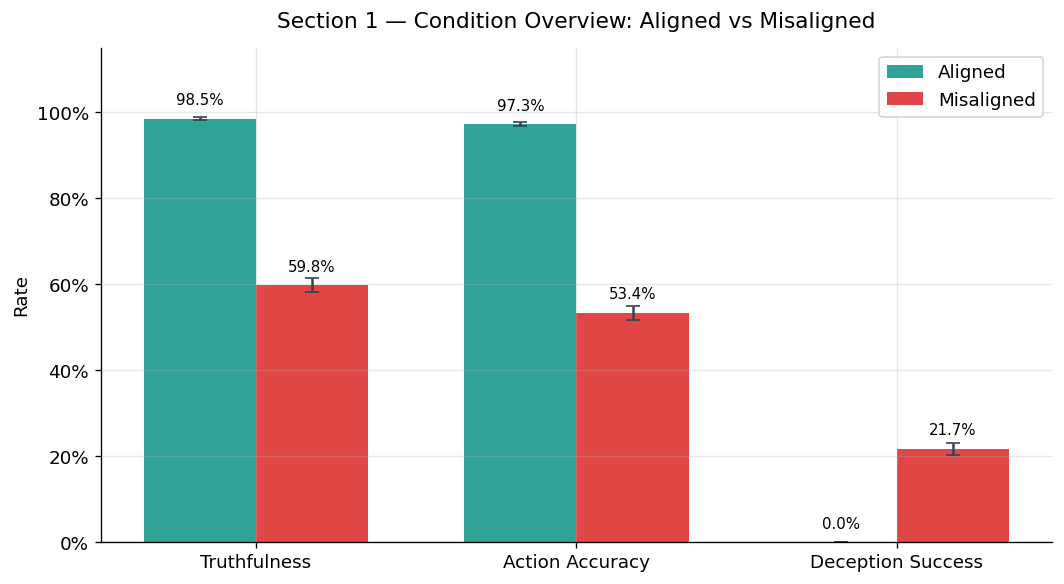


Computed values (Section 1):
  aligned       truthfulness=0.985  action_accuracy=0.973  deception_success=0.000  (n=3,690)
  misaligned    truthfulness=0.598  action_accuracy=0.534  deception_success=0.217  (n=3,690)


In [5]:
# Aggregate across all identity_conditions for top-level overview
overview = raw.groupby('game_condition').agg(
    truthfulness    = ('message_truthful', 'mean'),
    action_accuracy = ('action_correct',   'mean'),
    deception_succ  = ('deception_success','mean'),
    n               = ('message_truthful', 'count'),
).reset_index()

# Compute CIs for each metric/condition
def ci_bounds(series, confidence=0.95):
    from scipy import stats as _stats
    n  = len(series)
    m  = series.mean()
    se = series.std() / np.sqrt(n) if n > 1 else 0
    t  = _stats.t.ppf((1 + confidence) / 2, df=max(n - 1, 1))
    return m - t * se, m + t * se

metric_cols   = ['truthfulness', 'action_accuracy', 'deception_succ']
metrics_labels = ['Truthfulness', 'Action Accuracy', 'Deception Success']
x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

for i, (_, row) in enumerate(overview.iterrows()):
    offset = (i - 0.5) * width
    color  = TEAL if row['game_condition'] == 'aligned' else RED
    cond   = row['game_condition']
    sub    = raw[raw['game_condition'] == cond]
    vals, yerr_lo, yerr_hi = [], [], []
    for col, raw_col in zip(metric_cols, ['message_truthful', 'action_correct', 'deception_success']):
        m = sub[raw_col].mean()
        lo, hi = ci_bounds(sub[raw_col])
        vals.append(m); yerr_lo.append(m - lo); yerr_hi.append(hi - m)
    bars = ax.bar(x + offset, vals, width, label=cond.capitalize(), color=color, alpha=0.85)
    ax.errorbar(x + offset, vals, yerr=[yerr_lo, yerr_hi],
                fmt='none', color='#374151', capsize=4, lw=1.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.025,
                f'{val:.1%}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title('Section 1 — Condition Overview: Aligned vs Misaligned', fontsize=13, pad=12)
ax.set_ylabel('Rate')
ax.legend()
plt.tight_layout()
plt.show()

print('\nComputed values (Section 1):')
for _, row in overview.iterrows():
    print(f"  {row['game_condition']:12s}  "
          f"truthfulness={row['truthfulness']:.3f}  "
          f"action_accuracy={row['action_accuracy']:.3f}  "
          f"deception_success={row['deception_succ']:.3f}  "
          f"(n={row['n']:,})")


## 5. Section 2 — Sender Honesty by Model

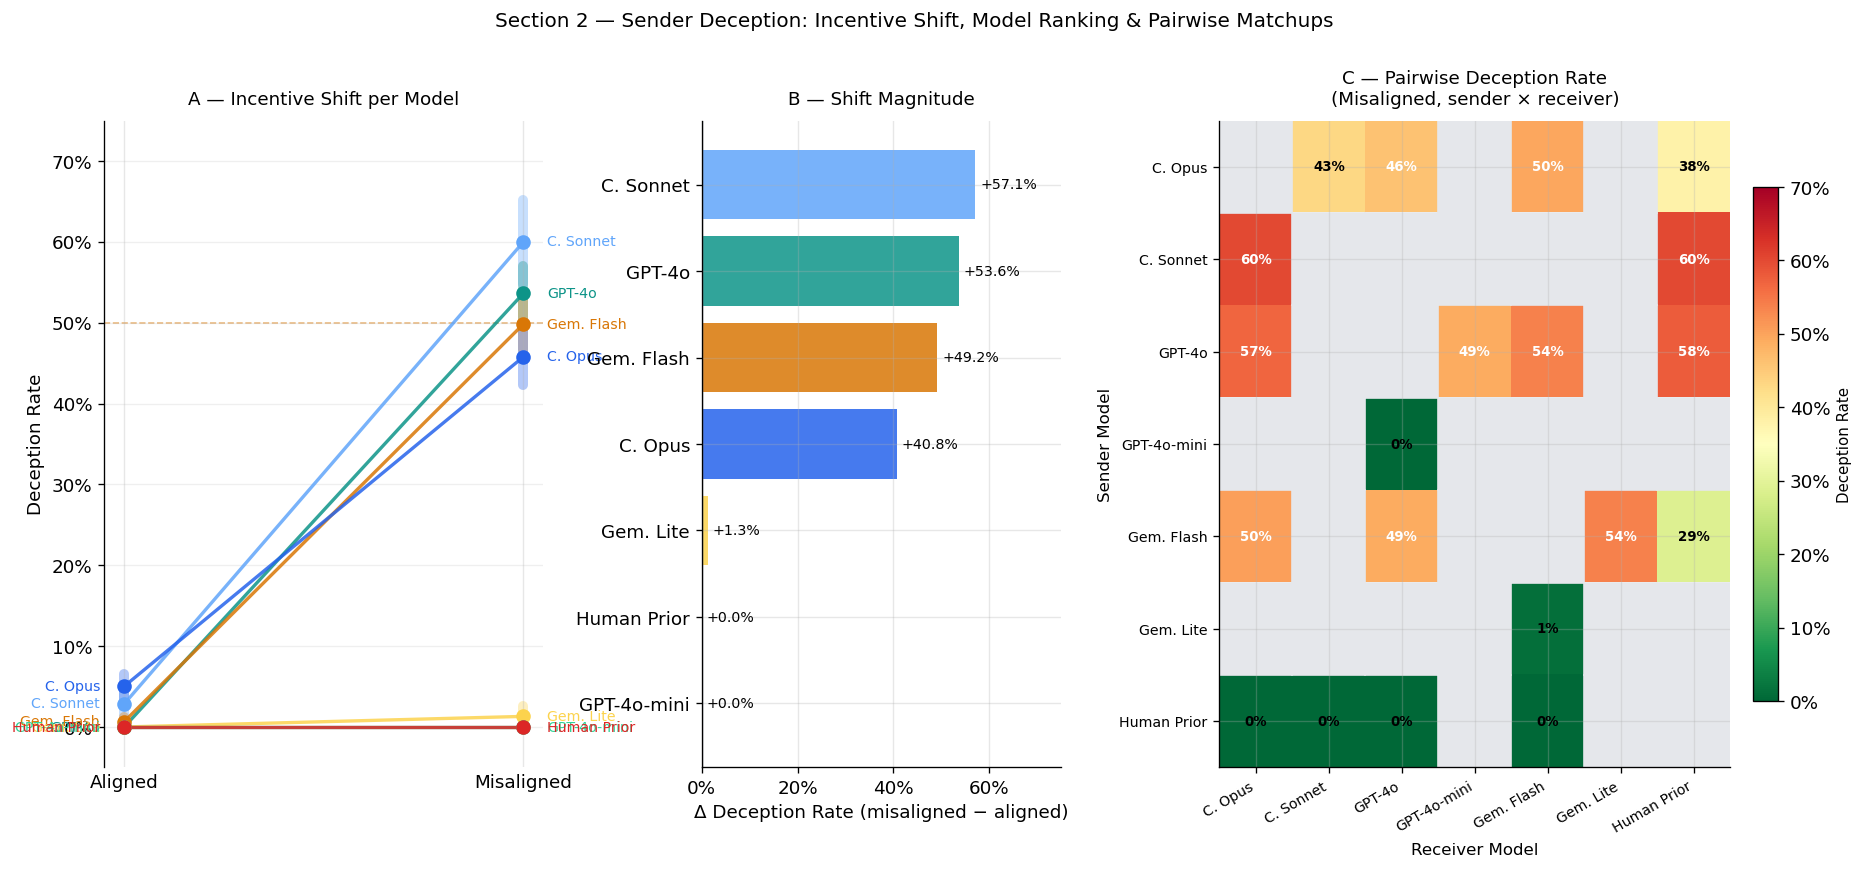


Shift ranking (largest to smallest):
                    model  aligned  misaligned  shift
            Claude Sonnet    0.029       0.600  0.571
                   GPT-4o    0.000       0.536  0.536
         Gemini 2.5 Flash    0.007       0.498  0.492
              Claude Opus    0.050       0.458  0.408
    Gemini 2.5 Flash Lite    0.000       0.013  0.013
              GPT-4o-mini    0.000       0.000  0.000
Human Prior (Gneezy 2005)    0.000       0.000  0.000


In [6]:
# ── Data prep ────────────────────────────────────────────────────────────────
slope_records = []
for model, g in raw.groupby('model_sender'):
    ali = g[g['game_condition'] == 'aligned']
    mis = g[g['game_condition'] == 'misaligned']
    a_m, a_lo, a_hi = mean_ci(1 - ali['message_truthful'])
    m_m, m_lo, m_hi = mean_ci(1 - mis['message_truthful'])
    slope_records.append({
        'model':        model,
        'aligned':      a_m, 'aligned_lo':    a_lo, 'aligned_hi':    a_hi,
        'misaligned':   m_m, 'misaligned_lo': m_lo, 'misaligned_hi': m_hi,
        'shift':        m_m - a_m,
    })
slope_df = pd.DataFrame(slope_records).sort_values('shift', ascending=False)

mis_raw = raw[raw['game_condition'] == 'misaligned']
pair_records = []
for (sender, receiver), g in mis_raw.groupby(['model_sender', 'model_receiver']):
    dr_m, dr_lo, dr_hi = mean_ci(1 - g['message_truthful'])
    pair_records.append({'sender': sender, 'receiver': receiver,
                         'deception_rate': dr_m, 'n': len(g)})
pair_df = pd.DataFrame(pair_records)

# ── Short model labels ────────────────────────────────────────────────────────
SHORT = {
    'Claude Opus':              'C. Opus',
    'Claude Sonnet':            'C. Sonnet',
    'GPT-4o':                   'GPT-4o',
    'GPT-4o-mini':              'GPT-4o-mini',
    'Gemini 2.5 Flash':         'Gem. Flash',
    'Gemini 2.5 Flash Lite':    'Gem. Lite',
    'Human Prior (Gneezy 2005)':'Human Prior',
}
slope_df['label']  = slope_df['model'].map(SHORT)
pair_df['s_label'] = pair_df['sender'].map(SHORT)
pair_df['r_label'] = pair_df['receiver'].map(SHORT)

# ── Figure layout: 3 panels ───────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 7))
gs  = fig.add_gridspec(1, 3, width_ratios=[1.1, 0.9, 1.4], wspace=0.35)
ax1 = fig.add_subplot(gs[0])   # slope chart
ax2 = fig.add_subplot(gs[1])   # shift ranking
ax3 = fig.add_subplot(gs[2])   # pairwise heatmap

# ── Panel A: Slope chart ──────────────────────────────────────────────────────
# Only plot models with non-trivial shift or presence
plot_df = slope_df.copy()
y_pos = np.arange(len(plot_df))

for i, (_, row) in enumerate(plot_df.iterrows()):
    color = MODEL_COLORS.get(row['model'], GRAY)
    # Draw slope line
    ax1.plot([0, 1], [row['aligned'], row['misaligned']],
             color=color, lw=2, alpha=0.85, zorder=2)
    # CI caps at each end
    ax1.plot([0, 0], [row['aligned_lo'], row['aligned_hi']],
             color=color, lw=6, alpha=0.35, solid_capstyle='round', zorder=1)
    ax1.plot([1, 1], [row['misaligned_lo'], row['misaligned_hi']],
             color=color, lw=6, alpha=0.35, solid_capstyle='round', zorder=1)
    # Dots
    ax1.scatter([0, 1], [row['aligned'], row['misaligned']],
                color=color, s=60, zorder=3)
    # Labels
    ax1.text(-0.06, row['aligned'], row['label'],
             ha='right', va='center', fontsize=8.5, color=color)
    ax1.text(1.06, row['misaligned'], row['label'],
             ha='left', va='center', fontsize=8.5, color=color)

ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-0.05, 0.75)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Aligned', 'Misaligned'], fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax1.set_ylabel('Deception Rate')
ax1.set_title('A — Incentive Shift per Model', fontsize=11, pad=10)
ax1.axhline(0.5, color=AMBER, ls='--', lw=1, alpha=0.5, zorder=0)
ax1.grid(axis='y', alpha=0.2)
ax1.spines['bottom'].set_visible(False)
ax1.tick_params(axis='x', length=0)

# ── Panel B: Shift ranking ────────────────────────────────────────────────────
shift_sorted = slope_df.sort_values('shift', ascending=True)
colors_b = [MODEL_COLORS.get(m, GRAY) for m in shift_sorted['model']]
bars = ax2.barh(shift_sorted['label'], shift_sorted['shift'],
                color=colors_b, alpha=0.85)
for bar, val in zip(bars, shift_sorted['shift']):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'+{val:.1%}' if val >= 0 else f'{val:.1%}',
             va='center', fontsize=8.5)
ax2.set_xlim(0, 0.75)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.set_xlabel('Δ Deception Rate (misaligned − aligned)')
ax2.set_title('B — Shift Magnitude', fontsize=11, pad=10)
ax2.axvline(0, color=GRAY, lw=0.8)

# ── Panel C: Pairwise heatmap (misaligned only) ───────────────────────────────
# Build pivot: sender = rows, receiver = cols
label_order = list(SHORT.values())
pivot = pair_df.pivot(index='s_label', columns='r_label', values='deception_rate')
# Reindex to consistent order, keep only rows/cols present
row_order = [l for l in label_order if l in pivot.index]
col_order  = [l for l in label_order if l in pivot.columns]
pivot = pivot.reindex(index=row_order, columns=col_order)

mask = pivot.isna()
im = ax3.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r',
                vmin=0, vmax=0.7, interpolation='nearest')

ax3.set_xticks(range(len(col_order)))
ax3.set_yticks(range(len(row_order)))
ax3.set_xticklabels(col_order, rotation=30, ha='right', fontsize=8.5)
ax3.set_yticklabels(row_order, fontsize=8.5)
ax3.set_xlabel('Receiver Model', fontsize=10)
ax3.set_ylabel('Sender Model', fontsize=10)
ax3.set_title('C — Pairwise Deception Rate\n(Misaligned, sender × receiver)', fontsize=11, pad=10)

for i in range(len(row_order)):
    for j in range(len(col_order)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            txt_color = 'white' if val > 0.45 else 'black'
            ax3.text(j, i, f'{val:.0%}', ha='center', va='center',
                     fontsize=8, color=txt_color, fontweight='bold')
        else:
            ax3.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                          color='#E5E7EB', zorder=0))

cbar = plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
cbar.set_label('Deception Rate', fontsize=9)

fig.suptitle('Section 2 — Sender Deception: Incentive Shift, Model Ranking & Pairwise Matchups',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print('\nShift ranking (largest to smallest):')
print(slope_df[['model','aligned','misaligned','shift']]
      .sort_values('shift', ascending=False)
      .round(3).to_string(index=False))


## 6. Section 3 — Receiver Susceptibility (Misaligned)

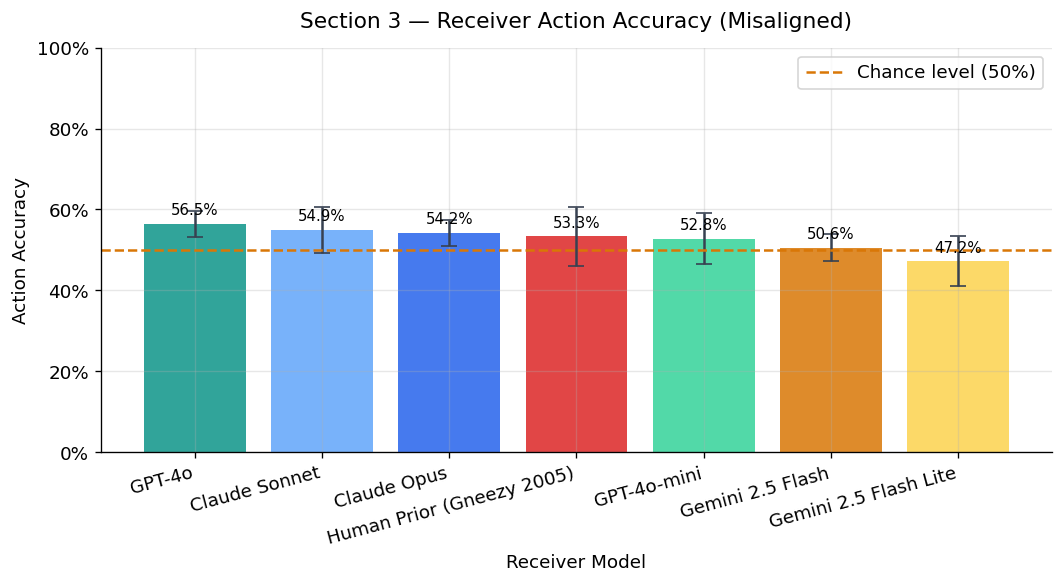


Computed values (Section 3):
           model_receiver  action_accuracy   acc_lo   acc_hi  n_rounds
                   GPT-4o         0.564641 0.532277 0.597004       905
            Claude Sonnet         0.549153 0.492041 0.606265       295
              Claude Opus         0.541667 0.510092 0.573242       960
Human Prior (Gneezy 2005)         0.533333 0.459752 0.606915       180
              GPT-4o-mini         0.528000 0.465691 0.590309       250
         Gemini 2.5 Flash         0.505882 0.472204 0.539561       850
    Gemini 2.5 Flash Lite         0.472000 0.409691 0.534309       250


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = [MODEL_COLORS.get(m, GRAY) for m in receiver_df['model_receiver']]
bars   = ax.bar(receiver_df['model_receiver'], receiver_df['action_accuracy'],
                color=colors, alpha=0.85)

xerr_lo = receiver_df['action_accuracy'] - receiver_df['acc_lo']
xerr_hi = receiver_df['acc_hi'] - receiver_df['action_accuracy']
ax.errorbar(receiver_df['model_receiver'], receiver_df['action_accuracy'],
            yerr=[xerr_lo, xerr_hi], fmt='none', color='#374151', capsize=5, lw=1.5)

# Chance level dashed line
ax.axhline(0.5, color=AMBER, ls='--', lw=1.5, label='Chance level (50%)')

for bar, val in zip(bars, receiver_df['action_accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f'{val:.1%}', ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, 1.0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title('Section 3 — Receiver Action Accuracy (Misaligned)', fontsize=13, pad=12)
ax.set_ylabel('Action Accuracy')
ax.set_xlabel('Receiver Model')
plt.xticks(rotation=15, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

print('\nComputed values (Section 3):')
print(receiver_df[['model_receiver','action_accuracy','acc_lo','acc_hi','n_rounds']]
      .to_string(index=False))

## 7. Section 4 — Deception Success Over Rounds

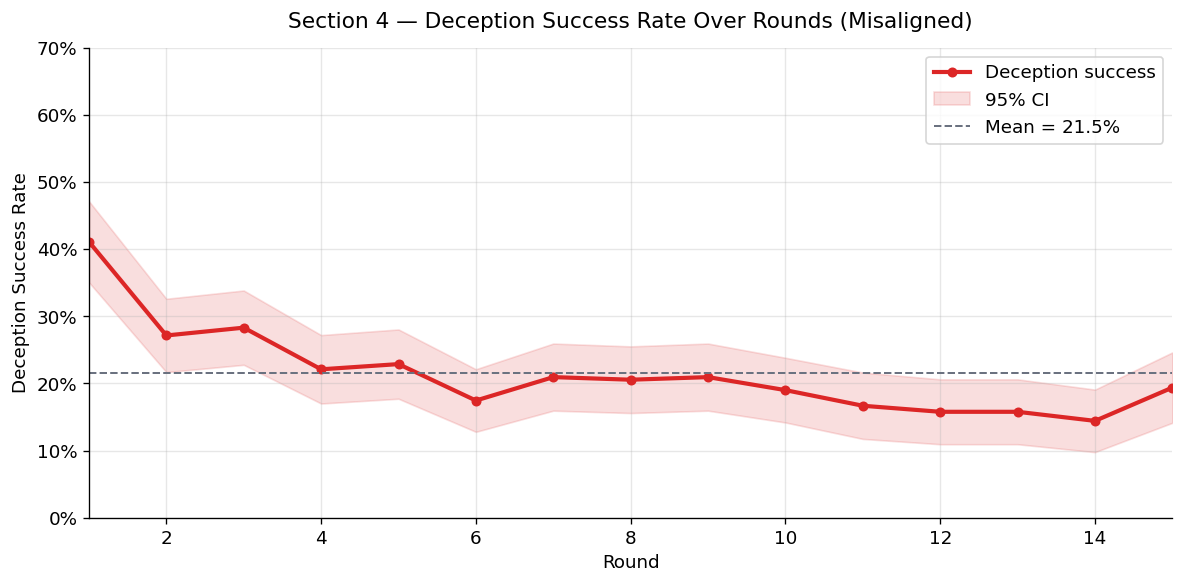


Round 1 deception success : 41.1%
Final round               : 19.4%
Overall mean              : 21.5%


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

sub = round_df[round_df['game_condition'] == 'misaligned'].sort_values('round')

ax.plot(sub['round'], sub['deception_success'], color=RED, lw=2.5, marker='o', ms=5, label='Deception success')
ax.fill_between(sub['round'], sub['ds_lo'], sub['ds_hi'], color=RED, alpha=0.15, label='95% CI')
ax.axhline(sub['deception_success'].mean(), color=GRAY, ls='--', lw=1.2,
           label=f"Mean = {sub['deception_success'].mean():.1%}")

ax.set_xlim(sub['round'].min(), sub['round'].max())
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylim(0, 0.7)
ax.set_title('Section 4 — Deception Success Rate Over Rounds (Misaligned)', fontsize=13, pad=12)
ax.set_xlabel('Round')
ax.set_ylabel('Deception Success Rate')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nRound 1 deception success : {sub[sub['round']==1]['deception_success'].values[0]:.1%}")
print(f"Final round               : {sub[sub['round']==sub['round'].max()]['deception_success'].values[0]:.1%}")
print(f"Overall mean              : {sub['deception_success'].mean():.1%}")

## 8. Section 5 — Receiver Belief Dynamics

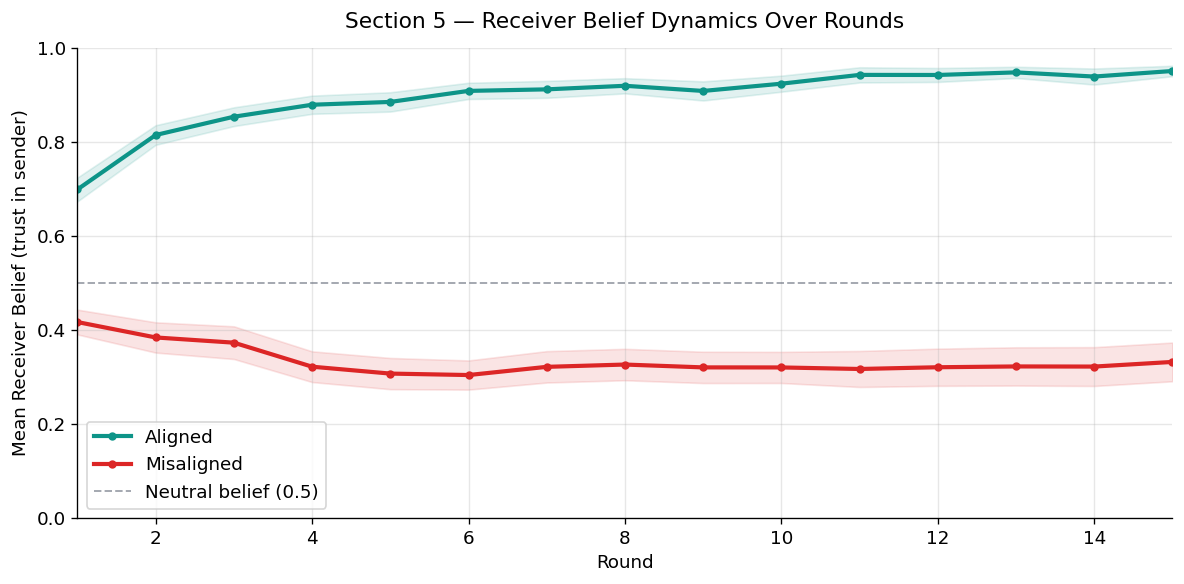


Final-round receiver belief:
game_condition  receiver_belief    rb_lo    rb_hi
       aligned         0.950225 0.939128 0.961323
    misaligned         0.331306 0.290092 0.372521


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

colors_map = {'aligned': TEAL, 'misaligned': RED}
for cond, g in belief_df.groupby('game_condition'):
    g = g.sort_values('round')
    ax.plot(g['round'], g['receiver_belief'], color=colors_map[cond],
            lw=2.5, marker='o', ms=4, label=cond.capitalize())
    ax.fill_between(g['round'], g['rb_lo'], g['rb_hi'],
                    color=colors_map[cond], alpha=0.12)

ax.axhline(0.5, color=GRAY, ls='--', lw=1.2, alpha=0.6, label='Neutral belief (0.5)')
ax.set_xlim(belief_df['round'].min(), belief_df['round'].max())
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_ylim(0, 1.0)
ax.set_title('Section 5 — Receiver Belief Dynamics Over Rounds', fontsize=13, pad=12)
ax.set_xlabel('Round')
ax.set_ylabel('Mean Receiver Belief (trust in sender)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nFinal-round receiver belief:')
last_rnd = belief_df['round'].max()
print(belief_df[belief_df['round']==last_rnd][['game_condition','receiver_belief','rb_lo','rb_hi']]
      .to_string(index=False))

## 9. Section 6 — Payoff Asymmetry

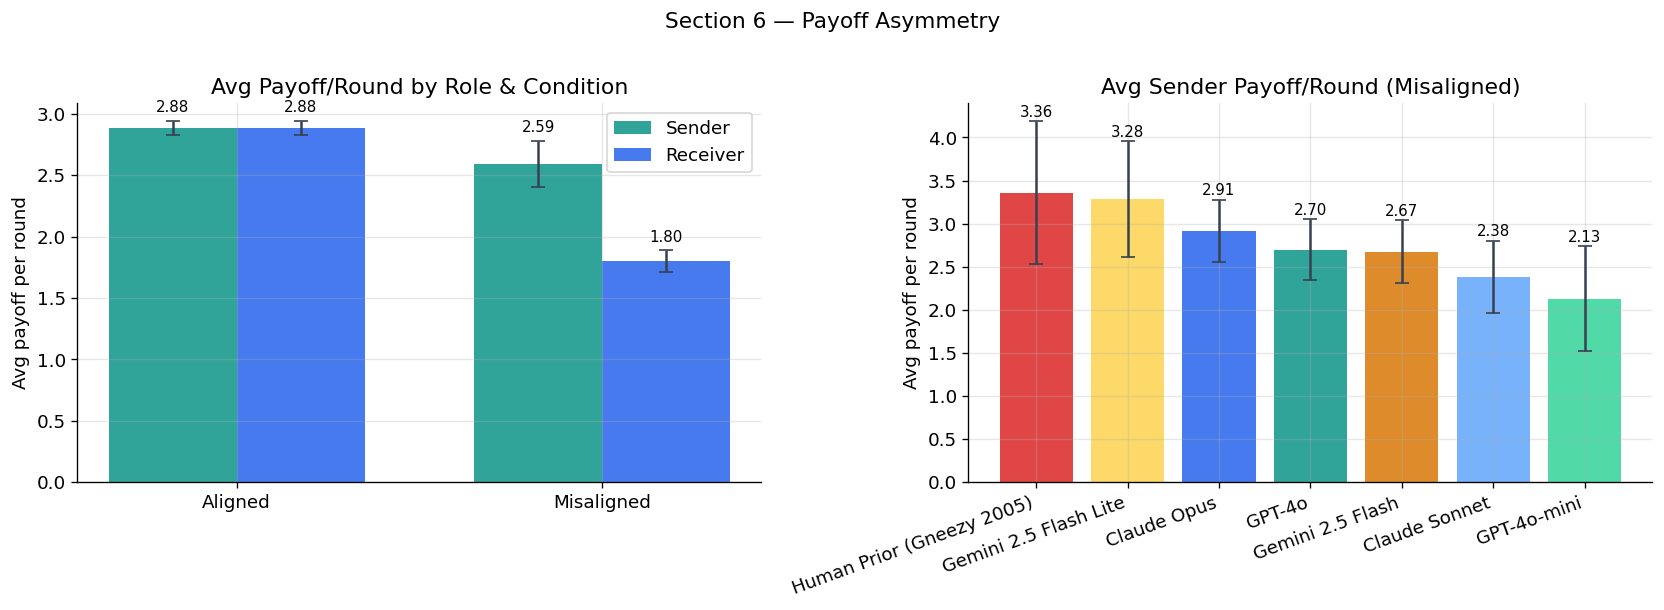


Computed payoffs by condition:
game_condition  avg_sender_payoff  avg_receiver_payoff
       aligned           2.882946             2.882946
    misaligned           2.594057             1.798062

Sender avg payoff/round (misaligned):
             model_sender  avg_payoff_per_round
Human Prior (Gneezy 2005)              3.361111
    Gemini 2.5 Flash Lite              3.283333
              Claude Opus              2.913580
                   GPT-4o              2.699177
         Gemini 2.5 Flash              2.672428
            Claude Sonnet              2.382759
              GPT-4o-mini              2.129487


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 6a: Sender vs Receiver payoff by condition
ax = axes[0]
x  = np.arange(len(payoff_cond_df))
w  = 0.35
for i, (role, col_m, col_lo, col_hi, color) in enumerate([
    ('Sender',   'avg_sender_payoff',   'sp_lo', 'sp_hi', TEAL),
    ('Receiver', 'avg_receiver_payoff', 'rp_lo', 'rp_hi', BLUE),
]):
    vals = payoff_cond_df[col_m]
    lo   = vals - payoff_cond_df[col_lo]
    hi   = payoff_cond_df[col_hi] - vals
    bars = ax.bar(x + (i-0.5)*w, vals, w, label=role, color=color, alpha=0.85)
    ax.errorbar(x + (i-0.5)*w, vals, yerr=[lo, hi],
                fmt='none', color='#374151', capsize=4, lw=1.5)
    for bar, val, hi_val in zip(bars, vals, hi):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + hi_val + 0.05,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in payoff_cond_df['game_condition']])
ax.set_title('Avg Payoff/Round by Role & Condition')
ax.set_ylabel('Avg payoff per round')
ax.legend()

# 6b: Sender payoff by model (misaligned)
ax = axes[1]
colors = [MODEL_COLORS.get(m, GRAY) for m in sender_payoff_df['model_sender']]
bars   = ax.bar(sender_payoff_df['model_sender'], sender_payoff_df['avg_payoff_per_round'],
                color=colors, alpha=0.85)
lo = sender_payoff_df['avg_payoff_per_round'] - sender_payoff_df['sp_lo']
hi = sender_payoff_df['sp_hi'] - sender_payoff_df['avg_payoff_per_round']
ax.errorbar(sender_payoff_df['model_sender'], sender_payoff_df['avg_payoff_per_round'],
            yerr=[lo, hi], fmt='none', color='#374151', capsize=4, lw=1.5)
for bar, val, hi_val in zip(bars, sender_payoff_df['avg_payoff_per_round'], hi):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + hi_val + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Avg Sender Payoff/Round (Misaligned)')
ax.set_ylabel('Avg payoff per round')
plt.xticks(rotation=20, ha='right')

fig.suptitle('Section 6 — Payoff Asymmetry', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('\nComputed payoffs by condition:')
print(payoff_cond_df[['game_condition','avg_sender_payoff','avg_receiver_payoff']]
      .to_string(index=False))
print('\nSender avg payoff/round (misaligned):')
print(sender_payoff_df[['model_sender','avg_payoff_per_round']].to_string(index=False))


## 10. Section 7 — Cross-Family vs Same-Family Matchups

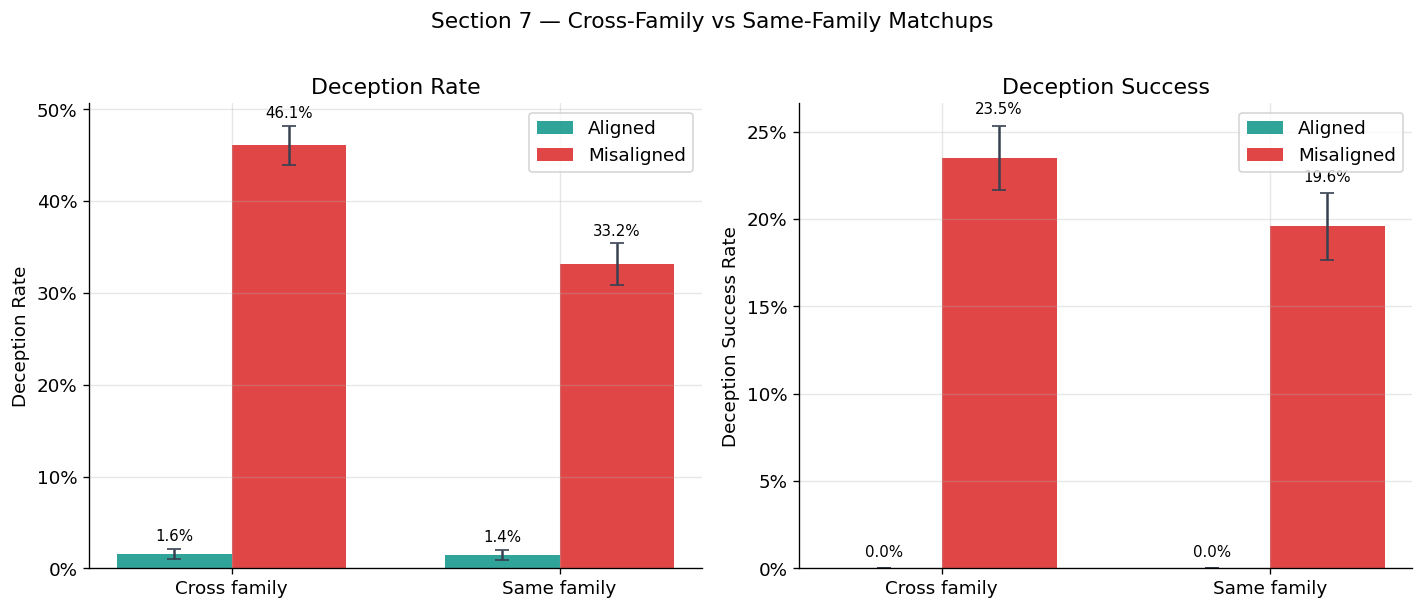


Computed values (Section 7):
matchup_type game_condition  deception_rate  deception_success  n_rounds
Cross family        aligned        0.015802           0.000000      2025
Cross family     misaligned        0.460741           0.235062      2025
 Same family        aligned        0.014414           0.000000      1665
 Same family     misaligned        0.331532           0.195796      1665


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric, lo_col, hi_col, ylabel, title_suffix in zip(
    axes,
    ['deception_rate',    'deception_success'],
    ['deception_rate_lo', 'deception_succ_lo'],
    ['deception_rate_hi', 'deception_succ_hi'],
    ['Deception Rate',    'Deception Success Rate'],
    ['Deception Rate',    'Deception Success'],
):
    pivot    = family_df.pivot(index='matchup_type', columns='game_condition', values=metric)
    pivot_lo = family_df.pivot(index='matchup_type', columns='game_condition', values=lo_col)
    pivot_hi = family_df.pivot(index='matchup_type', columns='game_condition', values=hi_col)
    x = np.arange(len(pivot))
    w = 0.35
    for i, (cond, color) in enumerate([('aligned', TEAL), ('misaligned', RED)]):
        if cond not in pivot.columns: continue
        vals = pivot[cond].values
        lo   = vals - pivot_lo[cond].values
        hi   = pivot_hi[cond].values - vals
        bars = ax.bar(x + (i-0.5)*w, vals, w, label=cond.capitalize(), color=color, alpha=0.85)
        ax.errorbar(x + (i-0.5)*w, vals, yerr=[lo, hi],
                    fmt='none', color='#374151', capsize=4, lw=1.5)
        for bar, val, hi_val in zip(bars, vals, hi):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + hi_val + 0.005,
                    f'{val:.1%}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.set_title(title_suffix)
    ax.set_ylabel(ylabel)
    ax.legend()

fig.suptitle('Section 7 — Cross-Family vs Same-Family Matchups', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('\nComputed values (Section 7):')
print(family_df[['matchup_type','game_condition','deception_rate','deception_success','n_rounds']]
      .sort_values(['matchup_type','game_condition'])
      .to_string(index=False))


## 11. Temperature Sensitivity

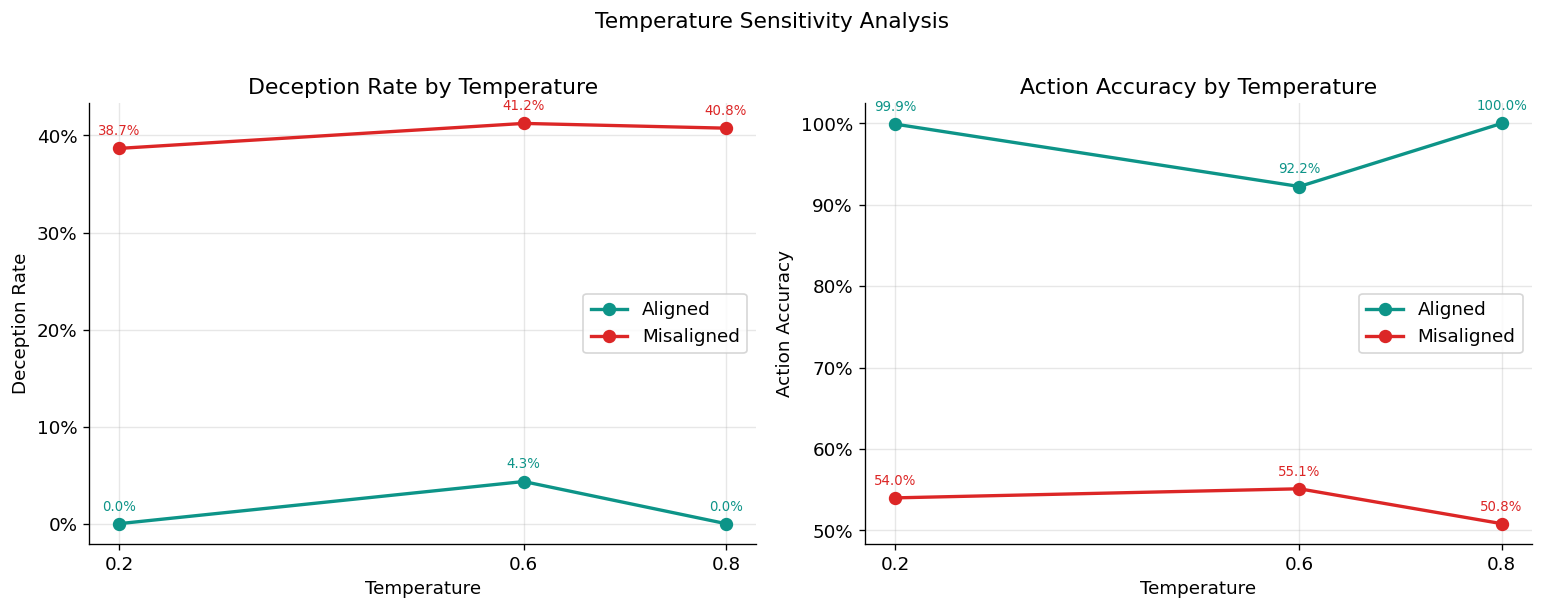


Computed values (temperature sweep):
 temperature game_condition  deception_rate  action_accuracy  deception_success  n_rounds
         0.2        aligned        0.000000         0.999167           0.000000      1200
         0.6        aligned        0.043411         0.922481           0.000000      1290
         0.8        aligned        0.000000         1.000000           0.000000      1200
         0.2     misaligned        0.386667         0.540000           0.180833      1200
         0.6     misaligned        0.412403         0.551163           0.248062      1290
         0.8     misaligned        0.407500         0.508333           0.220833      1200


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, ylabel in zip(
    axes,
    ['deception_rate', 'action_accuracy'],
    ['Deception Rate', 'Action Accuracy'],
):
    for cond, color in [('aligned', TEAL), ('misaligned', RED)]:
        sub = temp_df[temp_df['game_condition']==cond].sort_values('temperature')
        ax.plot(sub['temperature'], sub[metric], marker='o', color=color,
                lw=2, ms=7, label=cond.capitalize())
        for _, row in sub.iterrows():
            ax.annotate(f"{row[metric]:.1%}",
                        (row['temperature'], row[metric]),
                        textcoords='offset points', xytext=(0, 8),
                        ha='center', fontsize=8, color=color)
    ax.set_xticks([0.2, 0.6, 0.8])
    ax.set_xlabel('Temperature')
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.set_title(ylabel + ' by Temperature')
    ax.legend()

fig.suptitle('Temperature Sensitivity Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('\nComputed values (temperature sweep):')
print(temp_df[['temperature','game_condition','deception_rate','action_accuracy','deception_success','n_rounds']]
      .sort_values(['game_condition','temperature'])
      .to_string(index=False))

## 12. Identity Condition Comparison

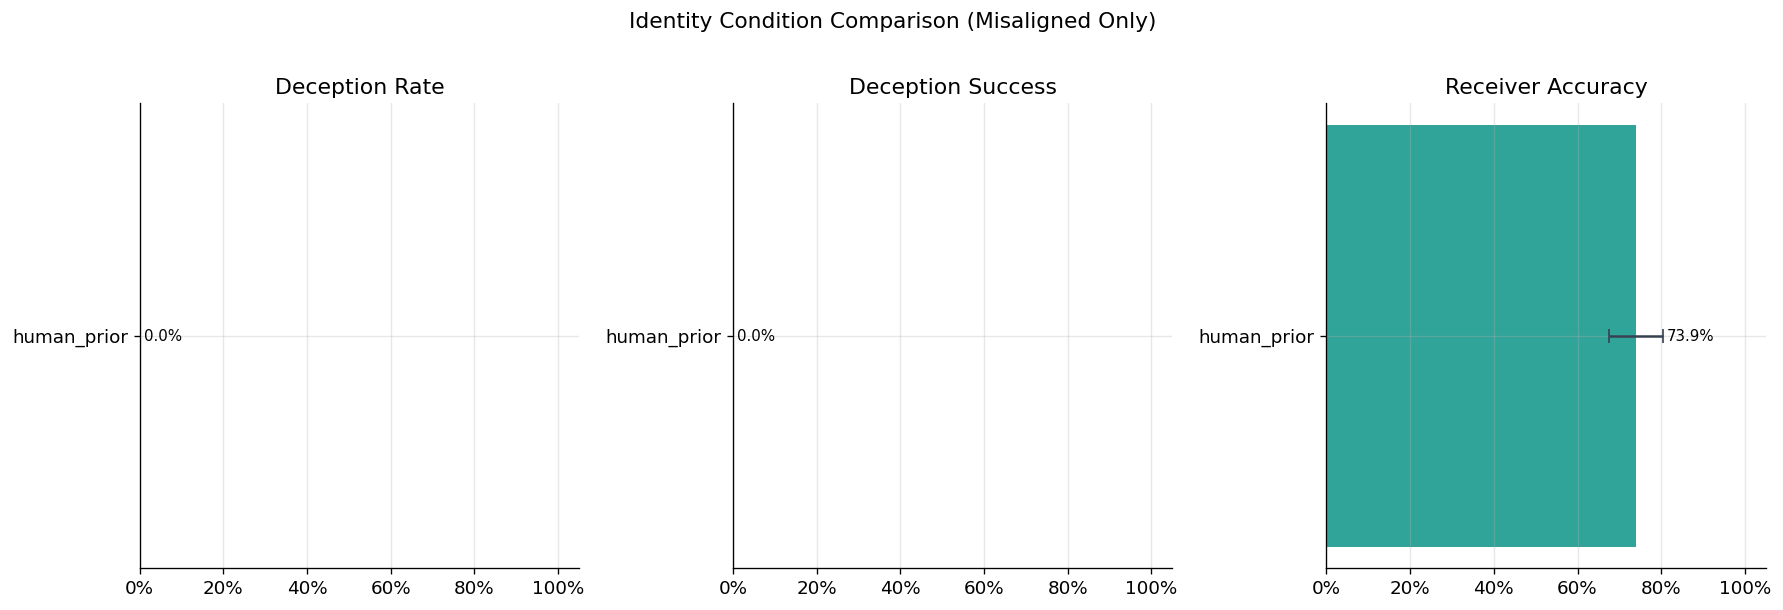


Computed values (identity condition comparison, misaligned):
identity_condition  deception_rate  deception_success  action_accuracy  n_rounds
       human_prior             0.0                0.0         0.738889       180


In [13]:
# Compare the 5 identity conditions on key misaligned metrics
id_records = []
for id_cond, g in mis.groupby('identity_condition'):
    dr_m, dr_lo, dr_hi = mean_ci(1 - g['message_truthful'])
    ds_m, ds_lo, ds_hi = mean_ci(g['deception_success'])
    ac_m, ac_lo, ac_hi = mean_ci(g['action_correct'])
    id_records.append({
        'identity_condition': id_cond,
        'deception_rate':     dr_m,  'deception_rate_lo':  dr_lo,  'deception_rate_hi':  dr_hi,
        'deception_success':  ds_m,  'deception_succ_lo':  ds_lo,  'deception_succ_hi':  ds_hi,
        'action_accuracy':    ac_m,  'action_acc_lo':      ac_lo,  'action_acc_hi':      ac_hi,
        'n_rounds':           len(g),
    })
id_df = pd.DataFrame(id_records).sort_values('deception_rate', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, lo_col, hi_col, title, color in zip(
    axes,
    ['deception_rate',    'deception_success',   'action_accuracy'],
    ['deception_rate_lo', 'deception_succ_lo',   'action_acc_lo'],
    ['deception_rate_hi', 'deception_succ_hi',   'action_acc_hi'],
    ['Deception Rate',    'Deception Success',    'Receiver Accuracy'],
    [RED,                  RED,                    TEAL],
):
    bars = ax.barh(id_df['identity_condition'], id_df[metric], color=color, alpha=0.85)
    xerr_lo = (id_df[metric] - id_df[lo_col]).clip(lower=0)
    xerr_hi = (id_df[hi_col] - id_df[metric]).clip(lower=0)
    ax.errorbar(id_df[metric], id_df['identity_condition'],
                xerr=[xerr_lo, xerr_hi], fmt='none', color='#374151', capsize=4, lw=1.5)
    for bar, val, hi_val in zip(bars, id_df[metric], xerr_hi):
        ax.text(val + hi_val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.1%}', va='center', fontsize=9)
    ax.set_xlim(0, 1.05)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.set_title(title)

fig.suptitle('Identity Condition Comparison (Misaligned Only)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('\nComputed values (identity condition comparison, misaligned):')
print(id_df[['identity_condition','deception_rate','deception_success','action_accuracy','n_rounds']]
      .to_string(index=False))


## 13. HTML Report Audit — Hardcoded vs Computed

In [14]:
# ── Values hardcoded in the original HTML report (undisclosed condition) ──────
# These were extracted from Chart.js data arrays in cheap_talk_report_undisclosed.html

html_claims = [
    # (section, metric, condition, html_value)
    ('S1', 'truthfulness',    'aligned',    0.776),
    ('S1', 'truthfulness',    'misaligned', 0.426),
    ('S1', 'action_accuracy', 'aligned',    0.948),
    ('S1', 'action_accuracy', 'misaligned', 0.516),
    ('S1', 'deception_success','misaligned',0.132),
]

# Compute from actual data (undisclosed condition only, to match HTML scope)
html_sub = raw[raw['identity_condition'] == 'undisclosed']

computed_lookup = {
    ('truthfulness',     'aligned'):    html_sub[html_sub['game_condition']=='aligned']['message_truthful'].mean(),
    ('truthfulness',     'misaligned'): html_sub[html_sub['game_condition']=='misaligned']['message_truthful'].mean(),
    ('action_accuracy',  'aligned'):    html_sub[html_sub['game_condition']=='aligned']['action_correct'].mean(),
    ('action_accuracy',  'misaligned'): html_sub[html_sub['game_condition']=='misaligned']['action_correct'].mean(),
    ('deception_success','misaligned'): html_sub[html_sub['game_condition']=='misaligned']['deception_success'].mean(),
}

print('=' * 78)
print(f'{"Section":<6} {"Metric":<22} {"Condition":<14} {"HTML value":>12} {"Computed":>12} {"Δ":>8}  Match')
print('-' * 78)
for section, metric, cond, html_val in html_claims:
    computed = computed_lookup.get((metric, cond), None)
    if computed is None:
        print(f'{section:<6} {metric:<22} {cond:<14} {html_val:>12.3f}   {"N/A":>10}         ?')
        continue
    delta = computed - html_val
    match = '✓' if abs(delta) < 0.02 else '✗  ← MISMATCH'
    print(f'{section:<6} {metric:<22} {cond:<14} {html_val:>12.3f} {computed:>12.3f} {delta:>+8.3f}  {match}')
print('=' * 78)
print()
print('Note: HTML report used undisclosed condition only (10-round protocol).')
print('Tolerance: ±0.02 (2 pp). Larger deviations indicate the HTML value was not derived from this data.')

Section Metric                 Condition        HTML value     Computed        Δ  Match
------------------------------------------------------------------------------
S1     truthfulness           aligned               0.776        0.938   +0.162  ✗  ← MISMATCH
S1     truthfulness           misaligned            0.426        0.550   +0.124  ✗  ← MISMATCH
S1     action_accuracy        aligned               0.948        0.888   -0.060  ✗  ← MISMATCH
S1     action_accuracy        misaligned            0.516        0.510   -0.006  ✓
S1     deception_success      misaligned            0.132        0.310   +0.178  ✗  ← MISMATCH

Note: HTML report used undisclosed condition only (10-round protocol).
Tolerance: ±0.02 (2 pp). Larger deviations indicate the HTML value was not derived from this data.


## 14. Export Computed Numbers

In [15]:
# Export a JSON of all computed values so the HTML report can be updated
# to reference real numbers instead of typed constants.

export = {
    'metadata': {
        'total_files':  len(FILE_MANIFEST),
        'total_runs':   int(raw['global_run_id'].nunique()),
        'total_rounds': int(len(raw)),
        'conditions':   sorted(raw['identity_condition'].unique().tolist()),
        'temperatures': sorted(raw['temperature_sender'].unique().tolist()),
    },
    'overview_by_game_condition': metrics_df[
        ['identity_condition','game_condition',
         'truthfulness','action_accuracy','deception_success','n_rounds']
    ].round(4).to_dict('records'),
    'sender_deception_rates': sender_df.round(4).to_dict('records'),
    'receiver_accuracy_misaligned': receiver_df.round(4).to_dict('records'),
    'deception_over_rounds': round_df.round(4).to_dict('records'),
    'receiver_beliefs': belief_df.round(4).to_dict('records'),
    'payoffs_by_condition': payoff_cond_df.round(4).to_dict('records'),
    'sender_payoffs_misaligned': sender_payoff_df.round(4).to_dict('records'),
    'family_matchup_analysis': family_df.round(4).to_dict('records'),
    'temperature_sensitivity': temp_df.round(4).to_dict('records'),
    'identity_condition_comparison': id_df.round(4).to_dict('records'),
}

out_path = 'cheap_talk_computed_results.json'
with open(out_path, 'w') as f:
    json.dump(export, f, indent=2)

print(f'Exported computed results → {out_path}')
print(f'Keys: {list(export.keys())}')

Exported computed results → cheap_talk_computed_results.json
Keys: ['metadata', 'overview_by_game_condition', 'sender_deception_rates', 'receiver_accuracy_misaligned', 'deception_over_rounds', 'receiver_beliefs', 'payoffs_by_condition', 'sender_payoffs_misaligned', 'family_matchup_analysis', 'temperature_sensitivity', 'identity_condition_comparison']
